# Distributional Reinforcement Learning with Quantile Regression

In [1]:
# 该仓库已包含 logger.py 与 rl_utils.py，无需额外下载。
pass

In [ ]:
import os
import gym
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import importlib

import logger as logger_module
import rl_utils as rl_utils_module

# 这里在普通的 Python 环境中，import 之后就不需要 reload 了，但在 Jupyter Notebook 中，修改了 logger.py 或 rl_utils.py 后，需要 reload 才能看到修改后的效果。
importlib.reload(logger_module)
importlib.reload(rl_utils_module)

Logger = logger_module.Logger
ReplayMemory = rl_utils_module.ReplayMemory
huber = rl_utils_module.huber

In [ ]:
class Network(nn.Module):
    def __init__(self, len_state, num_quant, num_actions):
        '''
        len_state: 状态的维度
        num_quant: 量子数，即每个动作对应的分位数的数量 todo
        num_actions: 动作的数量
        '''
        super().__init__()
        self.num_quant = num_quant
        self.num_actions = num_actions

        self.feature = nn.Sequential(
            nn.Linear(len_state, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
        )
        self.quantile_head = nn.Linear(256, num_actions * num_quant)

    def forward(self, x):
        x = self.feature(x)
        x = self.quantile_head(x)
        # 将输出的形状调整为 (batch_size, num_actions, num_quant)，其中 batch_size 是输入 x 的第一维大小。
        return x.view(-1, self.num_actions, self.num_quant)

    def q_values(self, x):
        # 计算每个动作的平均分位数作为该动作的 Q 值，返回形状为 (batch_size, num_actions) 的张量。
        # 看起来是求每个动作的Q值分布，然后对分布求平均，得到每个动作的平均Q值。
        return self.forward(x).mean(dim=2)

    def select_action(self, state, eps=0.0):
        # 将状态转换为张量，并添加批次维度，以便输入到网络中。
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        if state.dim() == 1:
            state = state.unsqueeze(0)

        # 如果是小于 eps 的随机数，则随机选择一个动作；否则，选择 Q 值最大的动作。
        if random.random() < eps:
            action = torch.randint(0, self.num_actions, (1,))
        else:
            with torch.no_grad():
                action = self.q_values(state).argmax(dim=1)
        return int(action.item())

In [ ]:
# 这边是用于更新eps参数的函数，随着训练的进行，eps 从 eps_start 逐渐衰减到 eps_end，衰减的速度由 eps_decay 控制。
eps_start, eps_end, eps_decay = 1.0, 0.05, 20_000

def epsilon_by_step(step):
    return eps_end + (eps_start - eps_end) * np.exp(-step / eps_decay)

In [17]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

env_name = 'MountainCar-v0'
env = gym.make(env_name)

try:
    env.reset(seed=seed)
except TypeError:
    pass

try:
    env.action_space.seed(seed)
except Exception:
    pass

memory = ReplayMemory(100_000)
logger = Logger('qrdqn', fmt={'loss': '.5f', 'eval_reward': '.2f'})

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

reset_out = env.reset()
state0 = reset_out[0] if isinstance(reset_out, tuple) else reset_out # 这里是针对新版本gym的reset函数返回值可能是一个元组的情况进行处理，确保state0是状态的数组。
state_dim = len(state0) # 其实这里可以不用这种方式获取状态维度，直接使用 env.observation_space.shape[0] 也可以。
action_dim = env.action_space.n
num_quant = 51 # 量子数，即每个动作对应的分位数的数量，这个是 QR-DQN 中的一个重要超参数，通常设置为 51 或 200 等。

# 构建预测网络和目标网络，并将目标网络的参数初始化为预测网络的参数。目标网络在训练过程中保持不变，用于计算目标值，定期更新以跟踪预测网络的变化。
Z = Network(len_state=state_dim, num_quant=num_quant, num_actions=action_dim).to(device)
Ztgt = Network(len_state=state_dim, num_quant=num_quant, num_actions=action_dim).to(device)
Ztgt.load_state_dict(Z.state_dict())
Ztgt.eval()

optimizer = optim.Adam(Z.parameters(), lr=1e-3)

In [ ]:
steps_done = 0
running_reward = None

# todo 这些参数的含义
gamma = 0.99
batch_size = 64
train_starts = 2_000
target_update_every = 1_000 # 每隔多少步将预测网络的参数复制到目标网络中，以保持目标网络的稳定性。
max_episodes = 500
max_steps_per_episode = 1_000

# todo
# tau 是分位数的权重，用于计算分位数回归的损失函数。
# # num_quant=51 时: [1/102, 3/102, 5/102, ..., 101/102]
# tau[i] 就是第 i 个分位点对应的分位数水平，均匀分布在 (0, 1) 之间。
# tau shape is (1, num_quant, 1)，表示每个分位点对应的权重，适用于批次大小为 1 的情况，在计算损失时会自动广播到整个批次。
tau = torch.tensor(
    (2 * np.arange(num_quant) + 1) / (2.0 * num_quant),
    dtype=torch.float32,
    device=device,
).view(1, num_quant, 1)

# 重置环境
def reset_env(env):
    out = env.reset()
    return out[0] if isinstance(out, tuple) else out

# 执行一步的环境交互
def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
    else:
        next_state, reward, done, info = out
    return next_state, reward, done, info

# 验证策略的函数，评估当前策略在环境中的表现，通常通过运行多个回合并计算平均奖励来衡量。
# 返回当前策略在环境中的平均奖励，通常用于监控训练过程中的性能提升。
@torch.no_grad()
def evaluate_policy(policy, env, episodes=5):
    rewards = []
    for _ in range(episodes):
        state = reset_env(env)
        done = False
        ep_reward = 0.0
        step = 0
        while not done and step < max_steps_per_episode:
            action = policy.select_action(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0), eps=0.0)
            state, reward, done, _ = step_env(env, action)
            ep_reward += reward
            step += 1
        rewards.append(ep_reward)
    return float(np.mean(rewards))

def train_step():
    '''
    训练模型
    '''
    # 采样一个批次的经验数据，包括状态、动作、奖励、下一个状态和是否结束。
    states, actions, rewards, next_states, dones = memory.sample(batch_size)
    states = states.to(device)
    actions = actions.view(-1).to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)
    dones = dones.to(device)

    # 根据实际选择的动作获取每个动作对应的Q值分布 
    # theta shape is (batch_size, num_quant)，表示每个样本对应的动作的分位数分布。
    theta = Z(states)[torch.arange(batch_size, device=device), actions]

    with torch.no_grad():
        next_actions = Z(next_states).mean(dim=2).argmax(dim=1) # 下一个执行的动作
        next_quantiles = Ztgt(next_states)[torch.arange(batch_size, device=device), next_actions] # 下一个执行动作的Q值分布 next_quantiles shape is (batch_size, num_quant)，表示每个样本对应的下一个动作的分位数分布。
        target_quantiles = rewards + gamma * (1.0 - dones) * next_quantiles # 下一个执行动作的bellman的分布值 target_quantiles shape is (batch_size, num_quant)，表示每个样本对应的下一个动作的bellman的分布值。
    
    # 计算实际值和预期值之间的两两的差异
    # unsqueeze(1) 中的1 表示在哪一个维度的位置插入一个新的维度，而不是扩展几个维度
    # diff shape is (batch_size, num_quant, num_quant)，表示每个样本对应的预测分位数和目标分位数之间的差异矩阵。
    diff = target_quantiles.unsqueeze(1) - theta.unsqueeze(2) 
    # diff.detach() < 0 最终得出的是一个bool值矩阵，通过float会转换为0和1的矩阵，表示预测值大于计算的Q值的部分为0，小于计算的Q值的部分为1。shape 是 (batch_size, num_quant, num_quant)
    # (diff < 0).float()：diff < 0 说明预测值 > 目标值（高估了），值为 1；否则为 0
    # tau - (diff < 0).float()：高估时（diff < 0）：权重 = |τ - 1| = 1 - τ；低估时（diff ≥ 0）：权重 = |τ - 0| = τ
    # 具体原理看 md文档中的解释，简单来说，这个权重是为了在计算分位数回归损失时，给予高估和低估不同的权重，以更好地拟合目标分位数分布。
    # 也可以理解为当处于tau 高值时，预测值要有90%以上的值要高于预测值，所以此时如果高于目标值，此时的权重就会比较小，反之如果低于目标值，此时的权重就会比较大。
    # 经过深度思考，我终于明白了：
    # 对于预测的分布你要当成一个分布，而不是一个具体的Q值处理
    # 当tau处于高位时，此时属于分布的最高位，那么这个点的概率分布就应该覆盖目标值的大部分值，所以diff应该大部分都是小于0的，所以weights应该都是较小值也就是0.1左右
    # 如果tau处于高位时，大部分预测值分布都低于目标值分布，那么就说明预测的分布远小于目标的分数，此时tau - 0 = tau 就会比较大，权重就会比较大。
    # 反之当tau处于低位时，此时属于分布的最低位，那么这个点的概率分布就应该覆盖目标值的小部分值，所以diff应该大部分都是大于0的，所以weights应该都是较小值也就是0.1左右
    # 如果tau处于低位时，大部分预测值分布都高于目标值分布，那么就说明预测的分布远大于目标的分数，此时tau - 1 = 1 - tau 就会比较大，权重就会比较大。
    weight = torch.abs(tau - (diff.detach() < 0).float()) 
    # 其实这里依旧是让两个分布之间的预测误差更小，从而接近
    # 这里是测量两个分布之间的两两之间的差异，让模型在反向传播求取梯度的过程中能够更加的稳定且指导该如何从整理分布的差距上调整分布的差异，避免因为大误差导致的梯度爆炸，同时也能够更好地拟合目标分位数分布。
    loss = (weight * huber(diff)).mean()

    # 优化模型，使得预测的分位数分布更接近目标分位数分布，使用 Huber 损失函数来计算损失，并进行反向传播和梯度裁剪，以稳定训练过程。
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(Z.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())

In [ ]:
for episode in range(1, max_episodes + 1): # 训练的主循环，迭代每个回合，直到达到最大回合数。
    state = reset_env(env)
    episode_reward = 0.0 # 记录每局的分数
    episode_loss = [] # 记录每局的损失

    for _ in range(max_steps_per_episode): # 最大步数限制，防止某些回合过长导致训练效率低下。
        steps_done += 1 # 记录总的步骤数，用于调整 epsilon 的值。
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        action = Z.select_action(state_tensor, epsilon_by_step(steps_done))
        next_state, reward, done, _ = step_env(env, action)

        # 存储
        memory.push(state, action, next_state, reward, float(done))
        episode_reward += reward
        state = next_state

        # 保证缓冲区只有到一定的长度后才会开始训练模型，避免在经验不足时进行训练导致模型性能不佳。
        if len(memory) >= train_starts:
            # 训练模型
            loss_value = train_step()
            episode_loss.append(loss_value)

            # 更新目标网络
            if steps_done % target_update_every == 0:
                Ztgt.load_state_dict(Z.state_dict())

        if done: # 游戏结束则提前结束
            break
    
    # 这种记录分数的方式适合有正负分数的环境，可以平滑分数的变化，避免分数波动过记录过程的影响。
    running_reward = episode_reward if running_reward is None else 0.1 * episode_reward + 0.9 * running_reward

    if episode % 20 == 0: # 每训练20个回合，评估一次当前策略的表现，并记录相关信息，包括当前回合数、总步骤数、当前 epsilon 的值、运行奖励、评估奖励和平均损失。
        eval_reward = evaluate_policy(Z, env, episodes=5)
        mean_loss = float(np.mean(episode_loss)) if episode_loss else 0.0
        logger.add(
            episode,
            steps=steps_done,
            eps=epsilon_by_step(steps_done),
            running_reward=running_reward,
            eval_reward=eval_reward,
            loss=mean_loss,
        )
        logger.iter_info()

# Vizualization

In [ ]:
import time
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

from matplotlib import rcParams
# 可视化前先设置一下图像的大小和分辨率，这样在 Jupyter Notebook 中显示的图像会更清晰。
rcParams['figure.figsize'] = 8, 3
rcParams['figure.dpi'] = 300

In [ ]:
# 这里是一些环境的动作名称，可以根据需要添加更多环境的动作名称。
# 用于在可视化过程中显示动作名称，而不是动作的索引，这样更直观。
# todo 具体用在哪里
actions={
    'CartPole-v0': ['Left', 'Right'],
    'MountainCar-v0': ['Left', 'Non', 'Right'],
}

In [ ]:
def get_plot(q):
    '''
    生成分位数分布的绘图数据。
    
    参数：
    q (numpy.ndarray): 分位数分布，形状为 (num_quant,)

    返回：
    x (list): x 坐标列表
    y (list): y 坐标列表
    '''
    eps, p = 1e-8, 0 # todo 用一个很小的偏移，避免完全重合点，帮助画出“台阶拐角”；
    x, y = [q[0]-np.abs(q[0]*0.2)], [0] # 在最左侧先补一个起点，让曲线从 y=0 开始。
    for i in range(0, len(q)): # 遍历每一个分位数的位置
        x += [q[i]-eps, q[i]]
        y += [p, p+1/len(q)]
        p += 1/len(q)
    x+=[q[i]+eps, q[i]+np.abs(q[i]*0.2)]
    y+=[1.0, 1.0]
    return x, y

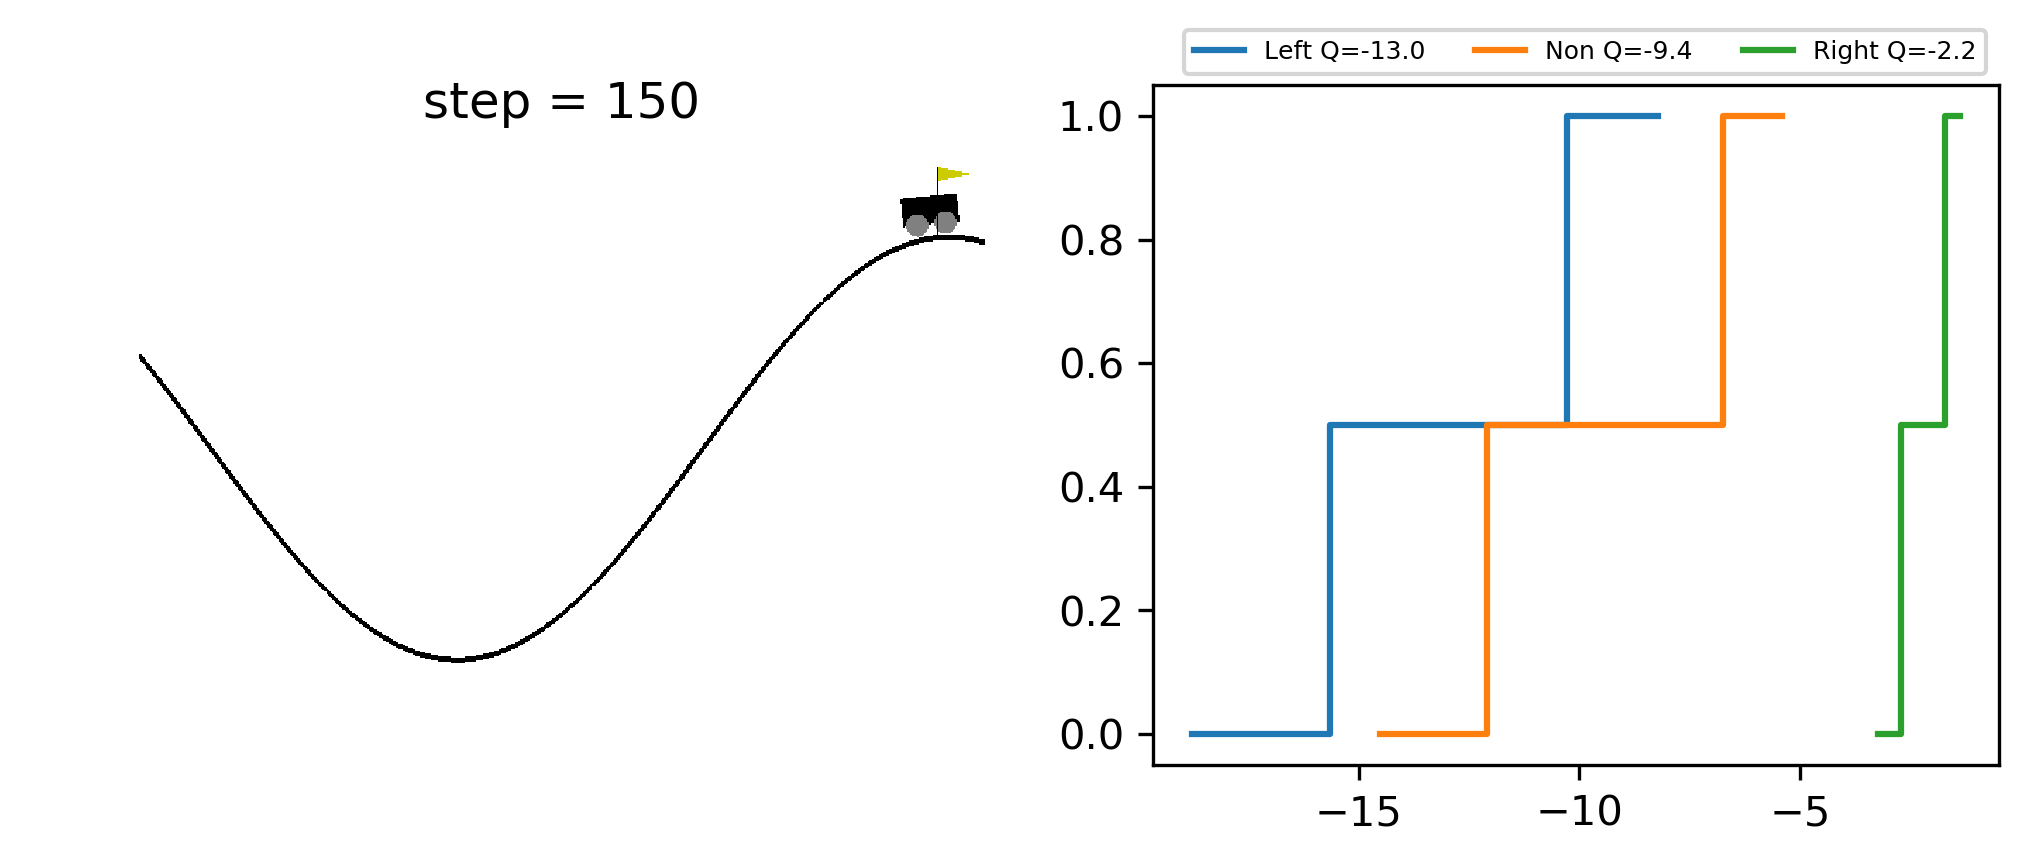

In [ ]:
# 可视化一个 episode（在本地 Jupyter 中可用）
state, done, steps = reset_env(env), False, 0
while not done and steps < 300:
    plt.clf() # 清空当前图像，为下一帧做准备
    steps += 1
    action = Z.select_action(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0), eps=0.0)
    state, reward, done, _ = step_env(env, action)

    plt.subplot(1, 2, 1)
    plt.title('step = %s' % steps)
    try:
        frame = env.render(mode='rgb_array')
    except TypeError:
        frame = env.render()
    plt.imshow(frame) # 显示环境的当前帧，通常是一个图像，展示了智能体在环境中的状态。
    plt.axis('off')

    plt.subplot(1, 2, 2) # 在同一行的第二列创建一个新的子图，用于显示每个动作的分位数分布。
    Zval = Z(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)).detach().cpu().numpy() # 获取当前状态下每个动作的分位数分布，形状为 (1, num_actions, num_quant)，然后将其转换为 NumPy 数组以便后续处理。
    for i in range(env.action_space.n): # 遍历每一个动作
        # Zval[0][i]：Zval[0]表示获取第一个样本数据，[0][i]表示获取第一个样本数据中第i个动作的分位数分布，形状为 (num_quant,)。
        # np.sort 对分数分布进行排序，方便后续绘图使用。
        x, y = get_plot(np.sort(Zval[0][i])) # todo
        plt.plot(x, y, label='%s Q=%.2f' % (actions[env_name][i], Zval[0][i].mean())) # 绘制每个动作的分位数分布曲线，并在图例中显示动作名称和对应的平均 Q 值。
    plt.legend(bbox_to_anchor=(1.0, 1.1), ncol=3, prop={'size': 6}) # todo 

    # 结合上下文：每次循环你先 plt.clf() 清掉上一帧的图内容，然后重新 subplot/imshow/plot 画出新的一帧，最后用 clear_output + display 把旧输出替换成新图，于是你看到的就是持续刷新的可视化过程
    display.clear_output(wait=True) # 清空当前单元格的输出区域（不是清空图像对象本身）。wait=True 的意思是：等到后面有新的输出要显示时再清空，这样能减少闪烁，让画面更平滑。
    display.display(plt.gcf()) # 把当前 Figure显示出来。plt.gcf() 是 get current figure，即“获取当前正在画的那张图
plt.clf()

In [ ]:
# 训练完成，保存模型
os.makedirs('checkpoints', exist_ok=True)
model_path = os.path.join('checkpoints', f'qrdqn_{env_name}.pt')
torch.save({'model_state_dict': Z.state_dict(), 'num_quant': num_quant, 'env_name': env_name}, model_path)
print('Model saved to:', model_path)

Model saved to: checkpoints\qrdqn_MountainCar-v0.pt
